In [1]:
# !pip install matplotlib numpy
import matplotlib.pyplot as plt
import numpy as np
from predictor_new import predict_future

In [2]:
# Version 1: Horizontal Straight Line
def generate_straight_trajectory_v1(t, start_pos=(0, 0), velocity=(200, 0)):
    """Generate position at time t for straight-line movement"""
    x = start_pos[0] + velocity[0] * t
    y = start_pos[1] + velocity[1] * t
    return (x, y)

# Version 2: Angled Straight Line
def generate_straight_trajectory_v2(t, start_pos=(0, 0), velocity=(30, 30)):
    """Generate position at time t for straight-line movement at 45 degrees"""
    x = start_pos[0] + velocity[0] * t
    y = start_pos[1] + velocity[1] * t
    return (x, y)

# Circle Trajectory
def generate_circle_trajectory(t, center=(200, 200), radius=100, angular_speed=1.0, phase=0):
    """Generate position at time t for circular movement"""
    angle = angular_speed * t + phase
    x = center[0] + radius * np.cos(angle)
    y = center[1] + radius * np.sin(angle)
    return (x, y)

# Version 1: Horizontal Sine Wave
def generate_sine_trajectory_v1(t, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2, phase=0):
    """Generate position at time t for sinusoidal movement (horizontal)"""
    x = start_pos[0] + x_velocity * t
    # Simple sine wave based on x position (adjust divisor as needed for wavelength)
    # The divisor controls how many spatial units correspond to one cycle
    y = start_pos[1] + amplitude * np.sin(2 * np.pi * frequency * x / (x_velocity * 1.5) + phase) 
    return (x, y)

# Version 2: Angled Sine Wave
def generate_sine_trajectory_v2(t, start_pos=(0, 0), angle_deg=-45, speed=40, amplitude=50, frequency=2, phase=0):
    """Generate position at time t for sinusoidal movement at an angle"""
    angle_rad = np.radians(angle_deg)
    base_x = start_pos[0] + speed * t * np.cos(angle_rad)
    base_y = start_pos[1] + speed * t * np.sin(angle_rad)
    perp_angle = angle_rad + np.pi/2
    x = base_x + amplitude * np.sin(2 * np.pi * frequency * t + phase) * np.cos(perp_angle)
    y = base_y + amplitude * np.sin(2 * np.pi * frequency * t + phase) * np.sin(perp_angle)
    return (x, y)

def add_noise(positions, noise_level=2.0):
    """Add Gaussian noise to a list of positions"""
    noisy_positions = []
    for pos in positions:
        noise_x = np.random.normal(0, noise_level)
        noise_y = np.random.normal(0, noise_level)
        noisy_positions.append((pos[0] + noise_x, pos[1] + noise_y))
    return noisy_positions

In [3]:
def run_and_plot_simulation(dt, n_steps, future_steps, noise_level, trajectory_generators, figure_title, seed=0, plot_clean_history=False):
    num_plots = len(trajectory_generators)
    fig, axes = plt.subplots(num_plots, 1, figsize=(8, 4 * num_plots))
    fig.suptitle(figure_title, fontsize=16)
    np.random.seed(seed)
    for i, (name, trajectory_func) in enumerate(trajectory_generators):
        ax = axes[i]
        print(f"Processing: {name}")

        # Generate trajectory data
        total_steps = n_steps + future_steps
        all_times = np.arange(0, total_steps * dt, dt)
        # Ensure enough points are generated
        if len(all_times) < total_steps:
             all_times = np.arange(0, (total_steps + 1) * dt, dt)[:total_steps]

        all_positions = [trajectory_func(t) for t in all_times]

        history_times = all_times[:n_steps]
        history_pos_clean = all_positions[:n_steps]
        actual_future_times = all_times[n_steps:total_steps]
        actual_future_pos = all_positions[n_steps:total_steps]

        # Add noise
        current_noise = noise_level
        if name == "Straight (Horizontal)": 
            # Less noise for straight line, this is just done because the straight line is really sensitive to the noise because of the short distance it travels in the examples.
            current_noise = noise_level / 3 if noise_level > 0 else 0 
            ax.set_ylim(-10, 10) # Zoom in for straight line

        history_pos_noisy = add_noise(history_pos_clean, current_noise)

        # Prepare history for predictor
        time_position_history = [[t, pos[0], pos[1]] for t, pos in zip(history_times, history_pos_noisy)]

        # Predict future
        predicted_future = predict_future(
            time_position_history, 
            future_times=actual_future_times,
            num_points=future_steps
        )

        # Convert to numpy arrays for plotting
        history_np_clean = np.array(history_pos_clean)
        history_np_noisy = np.array(history_pos_noisy)
        actual_future_np = np.array(actual_future_pos)
        # Ensure predicted_future is not empty before converting
        predicted_future_np = np.array(predicted_future) if predicted_future else np.empty((0,2))

        # --- Plotting ---
        # Plot actual future
        if actual_future_np.shape[0] > 0:
             ax.plot(actual_future_np[:, 0], actual_future_np[:, 1], 'g-', label="Actual Future", linewidth=2)
        
        # Plot predicted future if available
        if predicted_future_np.shape[0] > 0:
            ax.plot(predicted_future_np[:, 0], predicted_future_np[:, 1], 'r--', label="Predicted Future", linewidth=2)

        # Plot noisy history (input)
        if history_np_noisy.shape[0] > 0:
             ax.plot(history_np_noisy[:, 0], history_np_noisy[:, 1], 'bo', markersize=4, label="Input Points")

        # Plot clean history (ground truth)
        if history_np_clean.shape[0] > 0 and plot_clean_history:
             ax.plot(history_np_clean[:, 0], history_np_clean[:, 1], 'k--', label="Clean History", linewidth=2)
        
        # Add titles and labels
        ax.set_title(f"{name} - Noise σ: {current_noise:.2f} px")
        ax.set_xlabel("x position (pixels)")
        ax.set_ylabel("y position (pixels)")
        ax.legend()
        ax.grid(True)
        
        # Set aspect ratio for circle or rotated plots
        if "Circle" in name or "°" in name:
            ax.set_aspect('equal', adjustable='datalim')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

Processing: Straight
Model errors - Straight: 0.00, Circle: 34395.06, Sine: 0.00
Sine model selected but amplitude (0.00) below threshold (1.0).
Defaulting to straight line model instead.
Best model: straight
Processing: Circle
Model errors - Straight: 20179.23, Circle: 0.00, Sine: 1403.05
Circle model selected with radius: 100.00
Best model: circle
Processing: Sine
Model errors - Straight: 23738.65, Circle: 19663.19, Sine: 0.00
Sine model selected with amplitude: 50.00
Best model: sine


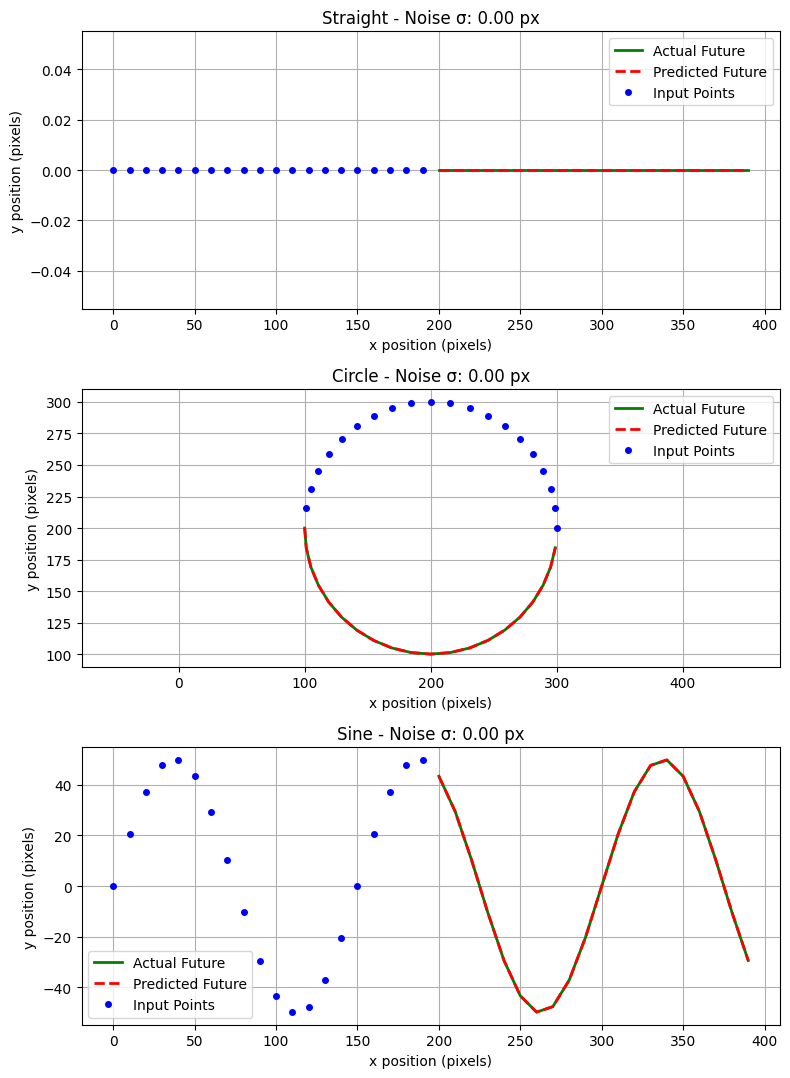

In [4]:
# Simulation parameters
dt_example = 0.05
n_steps_example = 20 # Total 1 second of history
future_steps_example = 20
noise_level_example = 0.0

# Trajectory generators 
trajectory_generators_example = [
    ("Straight", lambda t: generate_straight_trajectory_v1(t, start_pos=(0, 0), velocity=(200, 0))),
    ("Circle", lambda t: generate_circle_trajectory(t, center=(200, 200), radius=100, angular_speed=np.pi)),
    ("Sine", lambda t: generate_sine_trajectory_v1(t, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2))
]

# Title for the plot
figure_title_example = ''

# Call the function
run_and_plot_simulation(
    dt=dt_example,
    n_steps=n_steps_example,
    future_steps=future_steps_example,
    noise_level=noise_level_example,
    trajectory_generators=trajectory_generators_example,
    figure_title=figure_title_example
)

Processing: Straight (45°)
Model errors - Straight: 0.00, Circle: 1547.78, Sine: 0.00
Best model: straight
Processing: Circle
Model errors - Straight: 12914.71, Circle: 0.00, Sine: 897.95
Circle model selected with radius: 80.00
Best model: circle
Processing: Sine (-90°)
Model errors - Straight: 21439.05, Circle: 80299.50, Sine: 0.00
Sine model selected with amplitude: 50.00
Best model: sine


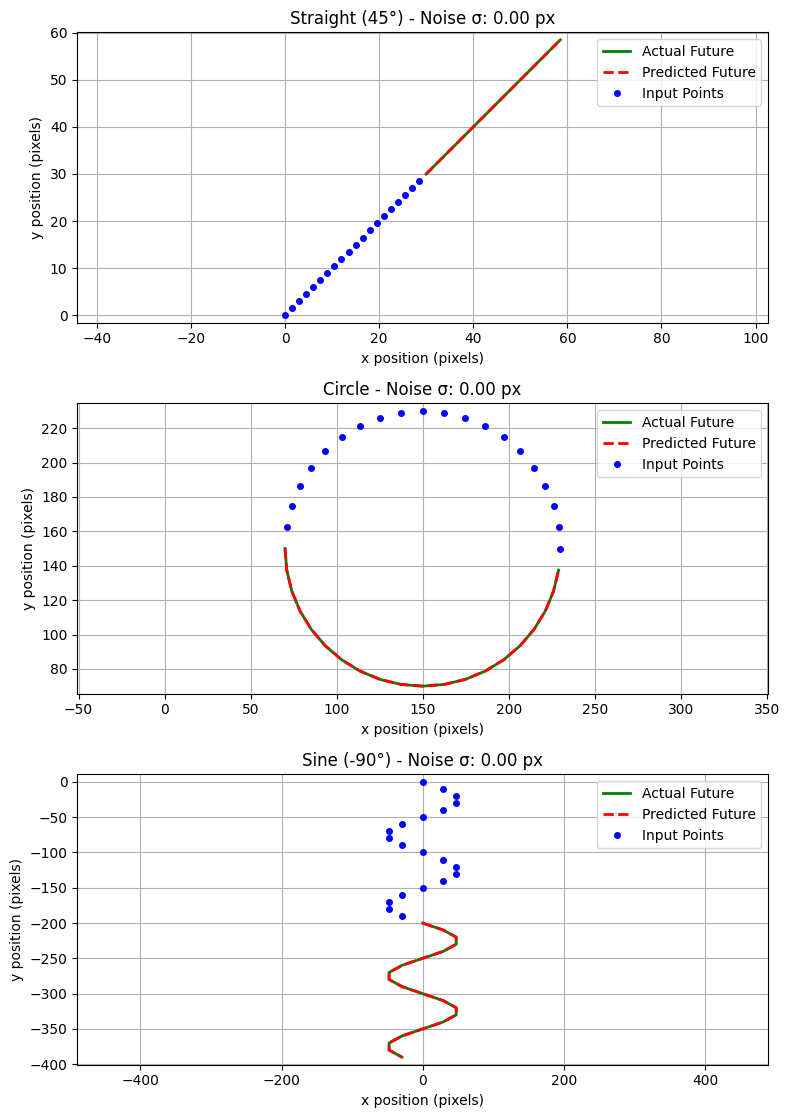

In [5]:
dt_v2 = 0.05
n_steps_v2 = 20
future_steps_v2 = 20
noise_level_v2 = 0.0

trajectory_generators_v2 = [
    ("Straight (45°)", lambda t: generate_straight_trajectory_v2(t, start_pos=(0, 0), velocity=(30, 30))),
    # Using different circle parameters for variety
    ("Circle", lambda t: generate_circle_trajectory(t, center=(150, 150), radius=80, angular_speed=np.pi)), 
    ("Sine (-90°)", lambda t: generate_sine_trajectory_v2(t, start_pos=(0, 0), angle_deg=-90, speed=200, amplitude=50, frequency=2))
]

# Create figure
fig2, axes2 = plt.subplots(len(trajectory_generators_v2), 1, figsize=(8, 12))
# fig2.suptitle('Demonstrating Rotated Trajectories', fontsize=16)

np.random.seed(0)

for i, (name, trajectory_func) in enumerate(trajectory_generators_v2):
    ax = axes2[i]
    print(f"Processing: {name}")

    # Generate trajectory data
    total_steps = n_steps_v2 + future_steps_v2
    all_times = np.arange(0, total_steps * dt_v2, dt_v2)
    all_positions = [trajectory_func(t) for t in all_times]

    history_times = all_times[:n_steps_v2]
    history_pos_clean = all_positions[:n_steps_v2]
    actual_future_times = all_times[n_steps_v2:total_steps]
    actual_future_pos = all_positions[n_steps_v2:total_steps]

    # Add noise
    current_noise = noise_level_v2
    if "Straight" in name:
        # Less noise for straight line, this is just done because the straight line is really sensitive to the noise because of the short distance is traveles in the examples.
        current_noise = noise_level_v2 / 3 
    history_pos_noisy = add_noise(history_pos_clean, current_noise)

    # Prepare history for predictor
    time_position_history = [[t, pos[0], pos[1]] for t, pos in zip(history_times, history_pos_noisy)]

    # Predict future
    predicted_future = predict_future(
        time_position_history, 
        future_times=actual_future_times,
        num_points=future_steps_v2
    )

    # Convert to numpy arrays for plotting
    history_np_clean = np.array(history_pos_clean)
    history_np_noisy = np.array(history_pos_noisy)
    actual_future_np = np.array(actual_future_pos)
    # Ensure predicted_future is not empty before converting
    predicted_future_np = np.array(predicted_future) if predicted_future else np.empty((0,2))

    # --- Plotting ---
    # Plot actual future (ground truth)
    ax.plot(actual_future_np[:, 0], actual_future_np[:, 1], 'g-', label="Actual Future", linewidth=2)
    
    # Plot predicted future if available
    if predicted_future_np.shape[0] > 0:
        ax.plot(predicted_future_np[:, 0], predicted_future_np[:, 1], 'r--', label="Predicted Future", linewidth=2)
    
    # Plot clean history (faded)
    # ax.plot(history_np_clean[:, 0], history_np_clean[:, 1], 'c.', alpha=0.5, label="True Historical Path")
    
    # Plot noisy history (input)
    ax.plot(history_np_noisy[:, 0], history_np_noisy[:, 1], 'bo', markersize=4, label="Input Points")

    ax.set_title(f"{name} - Noise σ: {current_noise:.2f} px")
    ax.set_xlabel("x position (pixels)")
    ax.set_ylabel("y position (pixels)")
    ax.legend()
    ax.grid(True)
    
    ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

### Low Noise

Processing: Straight (Horizontal)
Model errors - Straight: 4.47, Circle: 41.23, Sine: 4.21
Sine model selected but amplitude (0.16) below threshold (1.0).
Defaulting to straight line model instead.
Best model: straight
Processing: Circle
Model errors - Straight: 20135.94, Circle: 21.64, Sine: 1407.98
Circle model selected with radius: 99.35
Best model: circle
Processing: Sine (Horizontal)
Model errors - Straight: 23910.82, Circle: 20209.06, Sine: 38.70
Sine model selected with amplitude: 50.11
Best model: sine


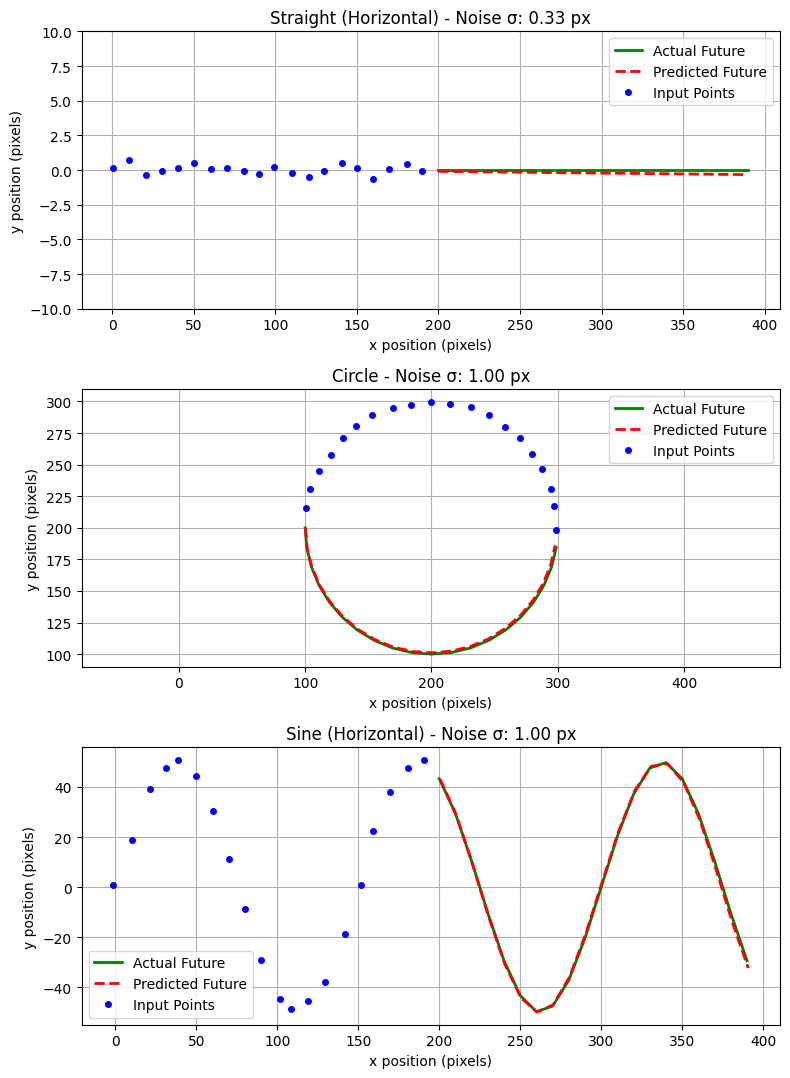

In [6]:
# Simulation parameters
dt_example = 0.05
n_steps_example = 20
future_steps_example = 20
noise_level_example = 1.0

# Trajectory generators 
trajectory_generators_example = [
    ("Straight (Horizontal)", lambda t: generate_straight_trajectory_v1(t, start_pos=(0, 0), velocity=(200, 0))),
    ("Circle", lambda t: generate_circle_trajectory(t, center=(200, 200), radius=100, angular_speed=np.pi)),
    ("Sine (Horizontal)", lambda t: generate_sine_trajectory_v1(t, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2))
]

figure_title_example = ''

# Call the function
run_and_plot_simulation(
    dt=dt_example,
    n_steps=n_steps_example,
    future_steps=future_steps_example,
    noise_level=noise_level_example,
    trajectory_generators=trajectory_generators_example,
    figure_title=figure_title_example
)

### Medium Noise

Processing: Straight (Horizontal)
Model errors - Straight: 40.22, Circle: 334.53, Sine: 39.00
Sine model selected but amplitude (0.33) below threshold (1.0).
Defaulting to straight line model instead.
Best model: straight
Processing: Circle
Model errors - Straight: 20177.79, Circle: 194.79, Sine: 1539.52
Circle model selected with radius: 98.00
Best model: circle
Processing: Sine (Horizontal)
Model errors - Straight: 24500.73, Circle: 21670.59, Sine: 348.23
Sine model selected with amplitude: 50.36
Best model: sine


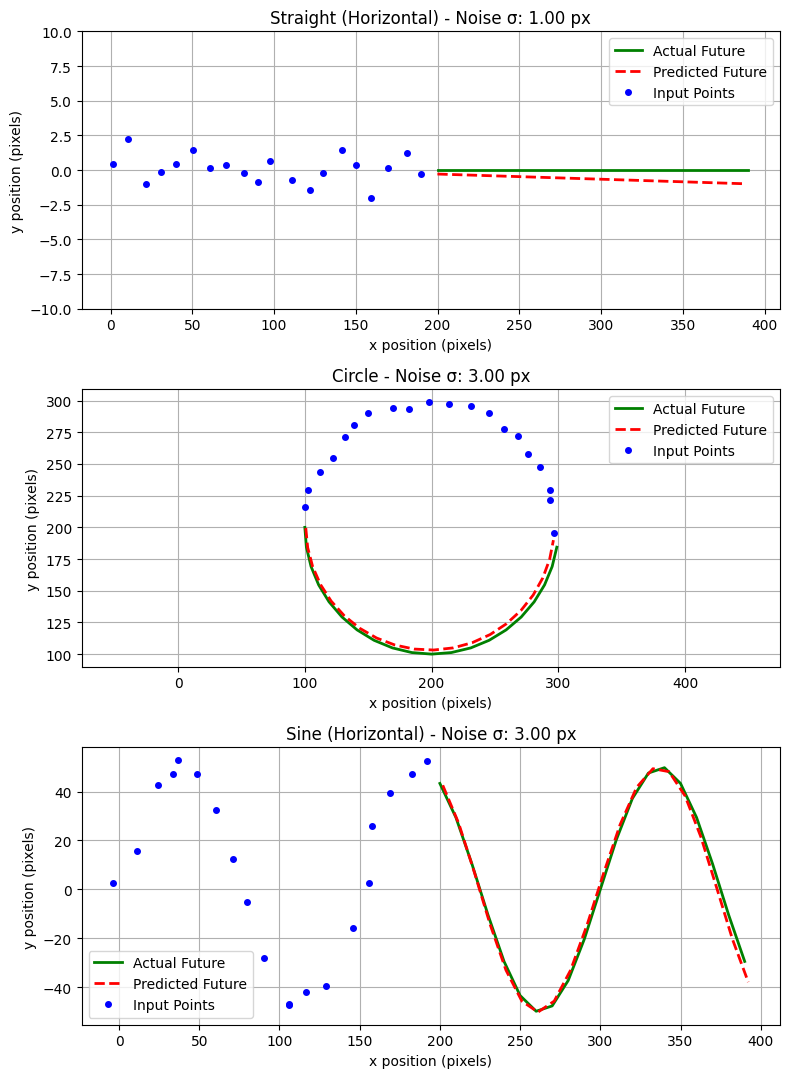

In [7]:
# Simulation parameters
dt_example = 0.05
n_steps_example = 20
future_steps_example = 20
noise_level_example = 3.0

# Trajectory generators 
trajectory_generators_example = [
    ("Straight (Horizontal)", lambda t: generate_straight_trajectory_v1(t, start_pos=(0, 0), velocity=(200, 0))),
    ("Circle", lambda t: generate_circle_trajectory(t, center=(200, 200), radius=100, angular_speed=np.pi)),
    ("Sine (Horizontal)", lambda t: generate_sine_trajectory_v1(t, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2))
]

figure_title_example = ''

# Call the function
run_and_plot_simulation(
    dt=dt_example,
    n_steps=n_steps_example,
    future_steps=future_steps_example,
    noise_level=noise_level_example,
    trajectory_generators=trajectory_generators_example,
    figure_title=figure_title_example
)

### High Noise

Processing: Straight (Horizontal)
Model errors - Straight: 160.88, Circle: 1126.82, Sine: 157.97
Sine model selected with amplitude: 11.99
Best model: sine
Processing: Circle
Model errors - Straight: 17643.08, Circle: 779.47, Sine: 1748.46
Circle model selected with radius: 95.55
Best model: circle
Processing: Sine (Horizontal)
Model errors - Straight: 25999.54, Circle: 24828.86, Sine: 1392.44
Sine model selected with amplitude: 50.79
Best model: sine


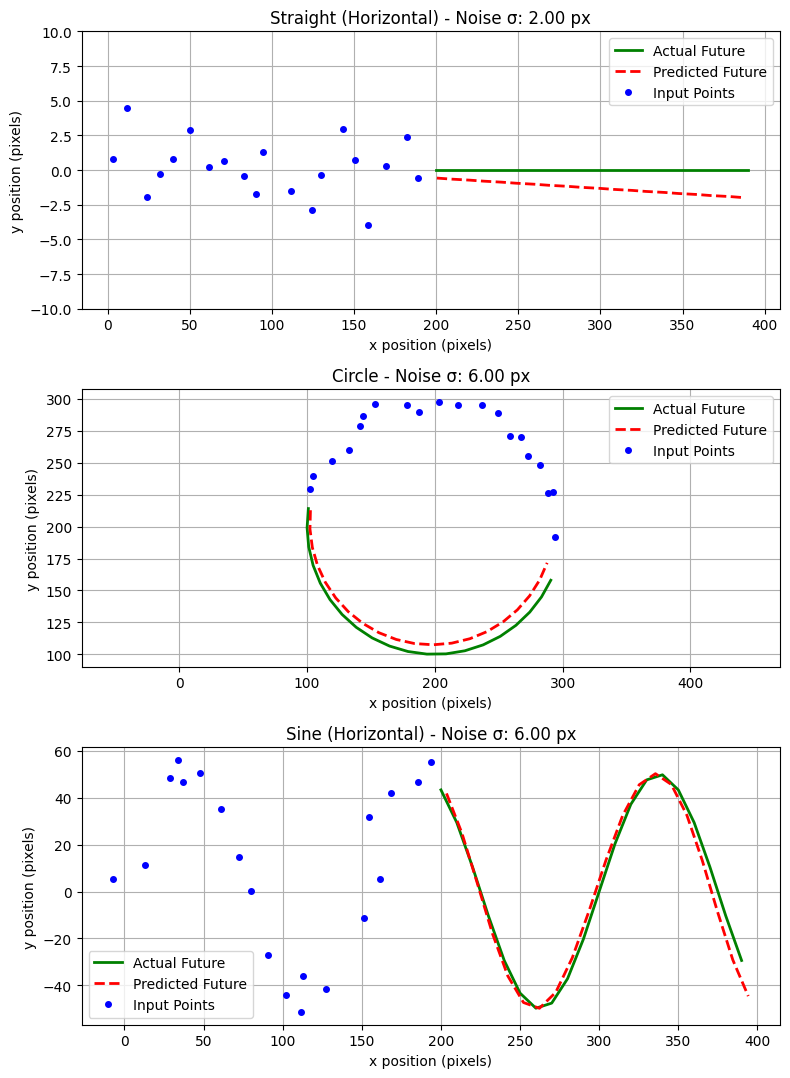

In [8]:
# Simulation parameters
dt_example = 0.05
n_steps_example = 20
future_steps_example = 20
noise_level_example = 6

# Trajectory generators 
trajectory_generators_example = [
    ("Straight (Horizontal)", lambda t: generate_straight_trajectory_v1(t, start_pos=(0, 0), velocity=(200, 0))),
    ("Circle", lambda t: generate_circle_trajectory(t, center=(200, 200), radius=100, angular_speed=3.0)),
    ("Sine (Horizontal)", lambda t: generate_sine_trajectory_v1(t, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2))
]

# Title for the plot
figure_title_example = ''

# Call the function
run_and_plot_simulation(
    dt=dt_example,
    n_steps=n_steps_example,
    future_steps=future_steps_example,
    noise_level=noise_level_example,
    trajectory_generators=trajectory_generators_example,
    figure_title=figure_title_example
)

### Pictures for methodology presentation

In [9]:
from predictor_new_visual import predict_future_visual

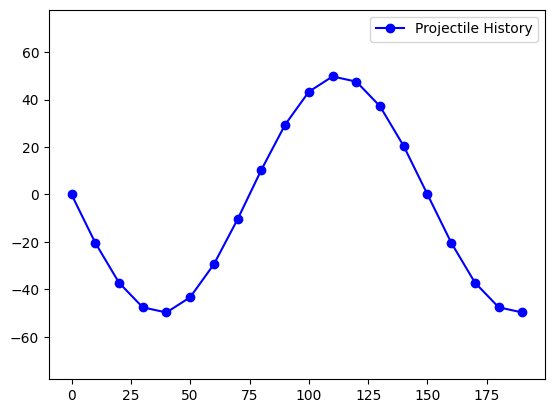

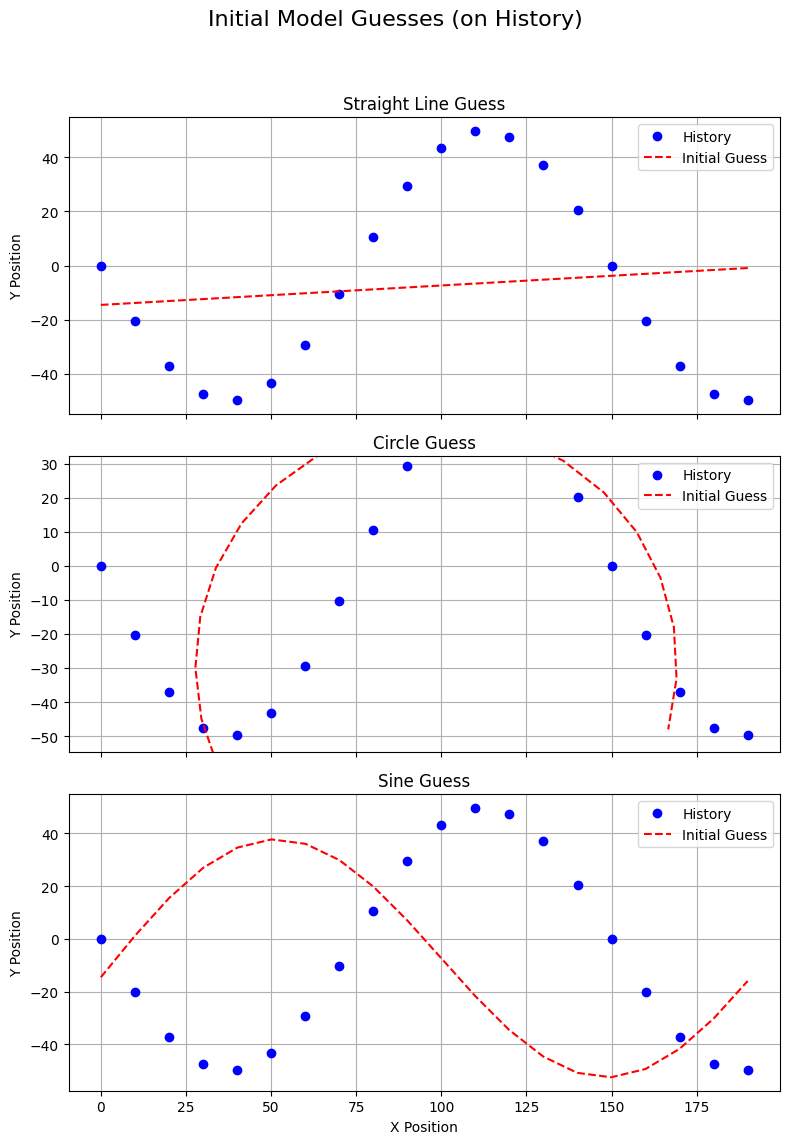

Model errors - Straight: 23738.65, Circle: 19663.19, Sine: 0.00
Circle model valid with radius: 70.72
Sine model valid with amplitude: 50.00
Best model selected: sine


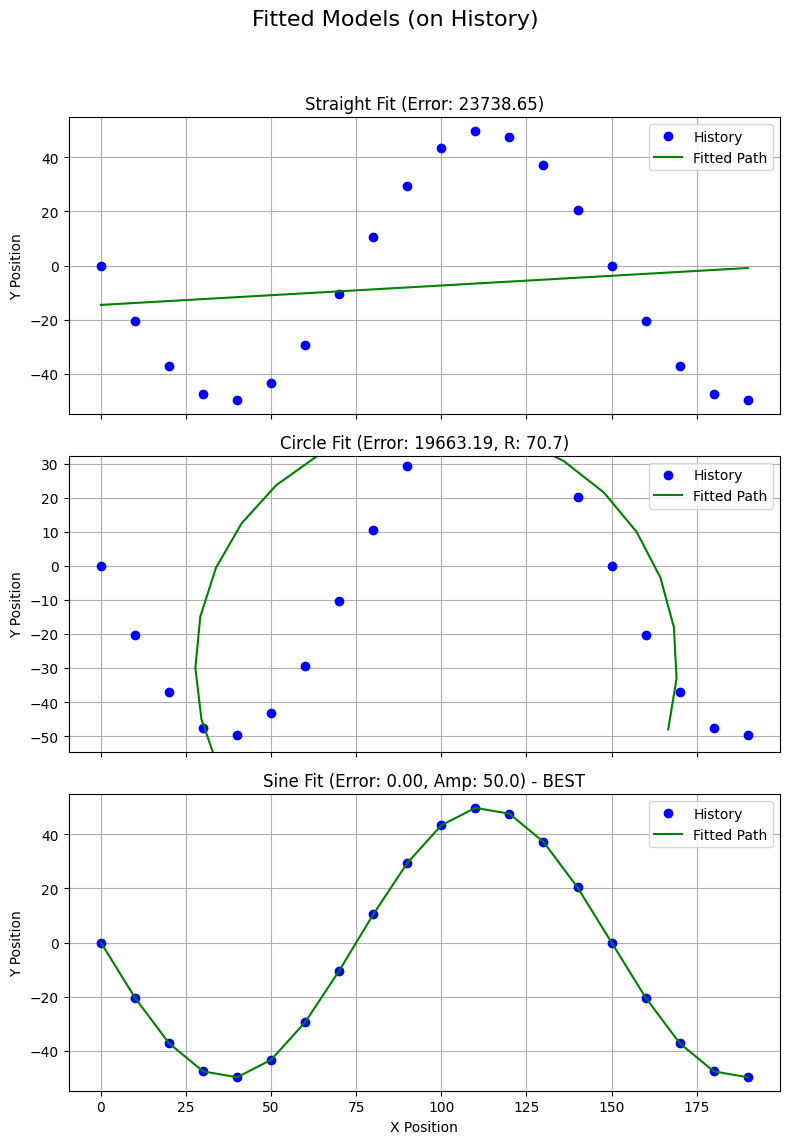

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


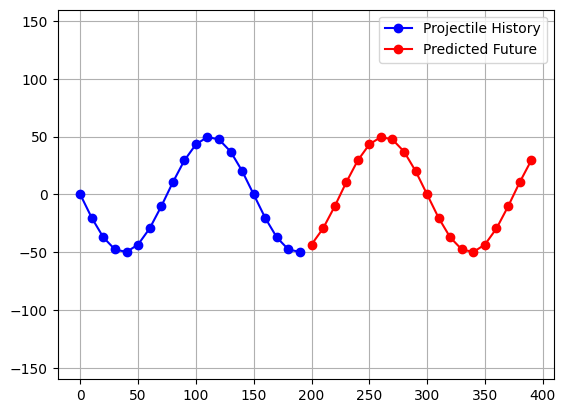

In [ ]:
# 1. Obtain history of positions for projectile
time_history = np.arange(0, 1.0, 0.05)  # 2 seconds of history
position_history = np.array(generate_sine_trajectory_v1(
    time_history, start_pos=(0, 0), x_velocity=200, amplitude=50, frequency=2, phase=np.pi
))
time_history, position_history
plt.axis('equal')
plt.plot(position_history[0, :], position_history[1, :], 'bo-', label="Projectile History")
plt.legend()
plt.show()

# 2, 3, 4, and 5. Create initial guess for the future trajectory for all models, Fit the models, select the best one, use it to predict future positions
future_positions = predict_future_visual(
    time_position_history=[
        [t, pos[0], pos[1]] for t, pos in zip(time_history, position_history.T)
    ], 
    future_times=np.arange(1.0, 2.0, 0.05), # 1 second of future prediction
    num_points=20 # Number of points to predict in the future
)

plt.axis('equal')
plt.plot(position_history[0, :], position_history[1, :], 'bo-', label="Projectile History")
plt.plot([pos[0] for pos in future_positions], [pos[1] for pos in future_positions], 'ro-', label="Predicted Future")
plt.legend()
# plt.ylim(-75, 75)
plt.grid()
plt.show()